In [1]:

import random
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Any
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from scipy.stats import ks_2samp

# Models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Dataviz
from matplotlib.colors import rgb2hex
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib
import seaborn as sns
import plotly.express as px


In [2]:

# --- Dataset Creation ---
X, y = make_classification(n_samples=1000, n_features=10, n_informative=4, flip_y=0.2, weights=[0.8, 0.1],random_state=42)
y = y.reshape(-1, 1)
df = pd.DataFrame(np.concatenate([X, y], axis=1))

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
df_train, df_test = train_test_split(df, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

x_columns = df.columns[:10]
y_column = df.columns[10]

X_train_df = df_train[x_columns]
X_test_df = df_test[x_columns]
y_train_df = df_train[y_column]
y_test_df = df_test[y_column]

In [3]:
model = LogisticRegression()
model.fit(X_train_df, y_train_df)

LogisticRegression()

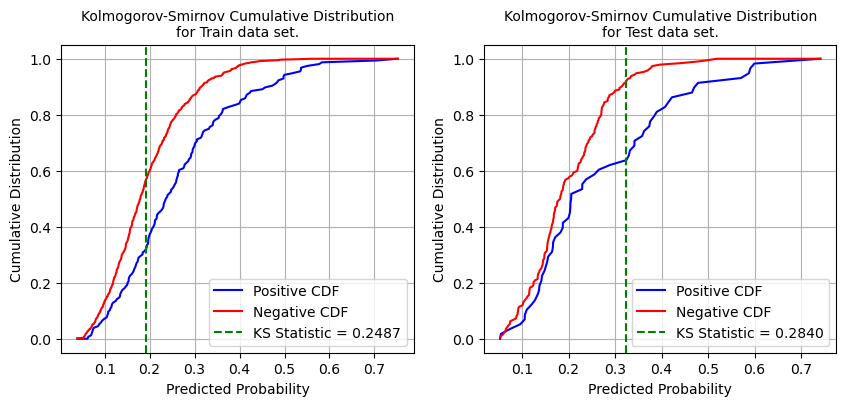

In [5]:

# def calculate_ks_df(model, X_list, y_list, name_list):
#     n = len(X_list)
#     results = {}

#     # Calculation
#     for i, (X, y, name) in enumerate(zip(X_list, y_list, name_list)):
#         true_labels = y
#         predicted_proba = model.predict_proba(X)[:, 1]

#         data = pd.DataFrame({
#             'true_labels': true_labels,
#             'predicted_proba': predicted_proba
#         })

#         # Separate the probabilities into two groups based on true labels
#         positive_proba = data[data['true_labels'] == 1]['predicted_proba']
#         negative_proba = data[data['true_labels'] == 0]['predicted_proba']

#         # Compute KS statistic and p-value using ks_2samp
#         ks_stat_, p_value = ks_2samp(positive_proba, negative_proba)

#         # Compute cumulative distributions
#         positive_cdf = np.sort(positive_proba)
#         positive_cdf_values = np.arange(1, len(positive_cdf) + 1) / len(positive_cdf)

#         negative_cdf = np.sort(negative_proba)
#         negative_cdf_values = np.arange(1, len(negative_cdf) + 1) / len(negative_cdf)

#         # Interpolation for a common set of points
#         eval_points = np.sort(np.unique(np.concatenate([positive_cdf, negative_cdf])))
#         pos_cdf_interp = np.interp(eval_points, positive_cdf, positive_cdf_values, left=0, right=1)
#         neg_cdf_interp = np.interp(eval_points, negative_cdf, negative_cdf_values, left=0, right=1)

#         # Calculate the KS statistic
#         ks_stat = np.max(np.abs(pos_cdf_interp - neg_cdf_interp))
#         ks_stat_position = eval_points[np.argmax(np.abs(pos_cdf_interp - neg_cdf_interp))]

#         df = pd.DataFrame({
#             'Predicted Probability': eval_points,
#             'Positive CDF': pos_cdf_interp,
#             'Negative CDF': neg_cdf_interp,
#             'Difference': np.abs(pos_cdf_interp - neg_cdf_interp)
#             })
#         results[name] = {
#             'df': df,
#             'ks_stat': ks_stat,
#             'ks_stat_position': ks_stat_position,
#             'ks_stat_': ks_stat_,
#         }

#     return results


def calculate_ks_df(dataset_dict):
    n = len(dataset_dict)
    results = {}

    # Calculation
    for name in dataset_dict:
        true_labels = dataset_dict[name]['y']
        predicted_proba = dataset_dict[name]['y_prob']
        # predicted_proba = model.predict_proba(X)[:, 1]

        data = pd.DataFrame({
            'true_labels': true_labels,
            'predicted_proba': predicted_proba
        })

        # Separate the probabilities into two groups based on true labels
        positive_proba = data[data['true_labels'] == 1]['predicted_proba']
        negative_proba = data[data['true_labels'] == 0]['predicted_proba']

        # Compute KS statistic and p-value using ks_2samp
        ks_stat_, p_value = ks_2samp(positive_proba, negative_proba)

        # Compute cumulative distributions
        positive_cdf = np.sort(positive_proba)
        positive_cdf_values = np.arange(1, len(positive_cdf) + 1) / len(positive_cdf)

        negative_cdf = np.sort(negative_proba)
        negative_cdf_values = np.arange(1, len(negative_cdf) + 1) / len(negative_cdf)

        # Interpolation for a common set of points
        eval_points = np.sort(np.unique(np.concatenate([positive_cdf, negative_cdf])))
        pos_cdf_interp = np.interp(eval_points, positive_cdf, positive_cdf_values, left=0, right=1)
        neg_cdf_interp = np.interp(eval_points, negative_cdf, negative_cdf_values, left=0, right=1)

        # Calculate the KS statistic
        ks_stat = np.max(np.abs(pos_cdf_interp - neg_cdf_interp))
        ks_stat_position = eval_points[np.argmax(np.abs(pos_cdf_interp - neg_cdf_interp))]

        df = pd.DataFrame({
            'Predicted Probability': eval_points,
            'Positive CDF': pos_cdf_interp,
            'Negative CDF': neg_cdf_interp,
            'Difference': np.abs(pos_cdf_interp - neg_cdf_interp)
            })
        results[name] = {
            'df': df,
            'ks_stat': ks_stat,
            'ks_stat_position': ks_stat_position,
            'ks_stat_': ks_stat_,
        }

    return results


def plot_ks(ks_results):
    # Plot cumulative distributions
    n = len(ks_results)
    fig, axes = plt.subplots(ncols=n, figsize=(5*n, 4), squeeze=False)

    for ax, (name, ks_dict) in zip(axes.flatten(), ks_results.items()):
        ax.plot(ks_dict['df']['Predicted Probability'], ks_dict['df']['Positive CDF'], label='Positive CDF', color='blue')
        ax.plot(ks_dict['df']['Predicted Probability'], ks_dict['df']['Negative CDF'], label='Negative CDF', color='red')
        ax.axvline(x=ks_dict['ks_stat_position'], color='green', linestyle='--', label=f'KS Statistic = {ks_dict["ks_stat"]:.4f}')
        ax.set_title(f'Kolmogorov-Smirnov Cumulative Distribution\nfor {name} data set.', fontsize=10)
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Cumulative Distribution')
        ax.legend()
        ax.grid()

    plt.close()
    return fig, axes



dataset_dict = {
    "Train":
    {
        "x": X_train_df,
        "y": y_train_df,
        "y_pred": model.predict(X_train_df),
        "y_prob": model.predict_proba(X_train_df)[:, 1],
    },
    "Test":
    {
        "x": X_test_df,
        "y": y_test_df,
        "y_pred": model.predict(X_test_df),
        "y_prob": model.predict_proba(X_test_df)[:, 1],
    },
}


ks_results = None
ks_results_ = calculate_ks_df(dataset_dict)
fig_, axes_ = plot_ks(ks_results_)
fig_


In [6]:

def plot_ks_plotly(ks_results):
    fig = go.Figure()
    buttons = []
    visibility = []

    for i, (name, ks_dict) in enumerate(ks_results.items()):
        df = ks_dict['df']
        x = df['Predicted Probability']
        pos_cdf = df['Positive CDF']
        neg_cdf = df['Negative CDF']
        ks_stat = ks_dict['ks_stat']
        ks_pos = ks_dict['ks_stat_position']

        # Add traces for this dataset
        fig.add_trace(go.Scatter(
            x=x, y=pos_cdf,
            mode='lines',
            name='Positive CDF',
            line=dict(color='blue'),
            visible=(i == 0)
        ))

        fig.add_trace(go.Scatter(
            x=x, y=neg_cdf,
            mode='lines',
            name='Negative CDF',
            line=dict(color='red'),
            visible=(i == 0)
        ))

        fig.add_trace(go.Scatter(
            x=[ks_pos, ks_pos], y=[0, 1],
            mode='lines',
            name=f'KS Statistic = {ks_stat:.4f}',
            line=dict(color='green', dash='dash'),
            visible=(i == 0)
        ))

        # Construct visibility array: only show traces for this dataset
        vis = [False] * len(ks_results) * 3  # 3 traces per dataset
        vis[i*3] = vis[i*3 + 1] = vis[i*3 + 2] = True

        # Create dropdown button
        buttons.append(dict(
            label=name,
            method="update",
            args=[
                {"visible": vis},
                {"title": f"Kolmogorov-Smirnov Cumulative Distribution<br>Dataset: {name}"}
            ]
        ))

    # Set layout with dropdown
    fig.update_layout(
        title=f"Kolmogorov-Smirnov Cumulative Distribution<br>Dataset: {list(ks_results.keys())[0]}",
        xaxis_title="Predicted Probability",
        yaxis_title="Cumulative Distribution",
        title_x=0.5,
        updatemenus=[
            {
                "buttons": buttons,
                "direction": "down",
                "x": -0.1,
                "xanchor": "left",
                "y": 1.15,
                "yanchor": "top",
            }
        ],
        # legend=dict(x=0.8, y=0.15),
        height=500
    )

    return fig


fig = plot_ks_plotly(ks_results_)
fig.show()
